# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [3]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("DataFrame users :\n")
print(users.isna().sum().sort_values(ascending=False),"\n")
print(users.isna().mean().sort_values(ascending=False)*100)


DataFrame users :

churn_date    3534
city           469
user_id          0
first_name       0
last_name        0
age              0
reg_date         0
plan             0
dtype: int64 

churn_date    88.350
city          11.725
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
reg_date       0.000
plan           0.000
dtype: float64


In [11]:
# cantidad de nulos para usage
print("DataFrame usage :\n")
print(usage.isna().sum().sort_values(ascending=False),"\n")
print(usage.isna().mean().sort_values(ascending=False)*100)

# Análisis de validez de  los datos nulos por tipo de servicio (llamada o mensaje)
print("\n\nCuando el tipo de comunicación es LLAMADA, NO hay VALORES FALTANTES en la columna 'duration' lo cual es correcto y se ajusta a la funcionalidad del negocio.\n")
print(usage[usage["type"] == "call"].isna().sum())
print("\n\nCuando el tipo de comunicación es MENSAJE DE TEXTO, NO hay VALORES FALTANTES en la columna 'length' lo cual es correcto y se ajusta a la funcionalidad del negocio.\n")
print(usage[usage["type"] == "text"].isna().sum())
users[users["user_id"]==10906]

DataFrame usage :

duration    22076
length      17896
date           50
id              0
user_id         0
type            0
dtype: int64 

duration    55.190
length      44.740
date         0.125
id           0.000
user_id      0.000
type         0.000
dtype: float64


Cuando el tipo de comunicación es LLAMADA, NO hay VALORES FALTANTES en la columna 'duration' lo cual es correcto y se ajusta a la funcionalidad del negocio.

id              0
user_id         0
type            0
date           26
duration        0
length      17896
dtype: int64


Cuando el tipo de comunicación es MENSAJE DE TEXTO, NO hay VALORES FALTANTES en la columna 'length' lo cual es correcto y se ajusta a la funcionalidad del negocio.

id              0
user_id         0
type            0
date           24
duration    22076
length          0
dtype: int64


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
906,10906,Mariana,Lopez,65,MTY,2022-09-06 01:54:30.517629408,Basico,NaN


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  - En el DataFrame users: encontramos valores faltantes en las columnas churn_date(cant.3534) y city(cant.469) que representan un 88.35% y 11.725% respectivamente.
  - En el DataFrame usage: encontramos valores faltantes en las columnas duration(Cant.22076), length(Cant.17896) y date(Cant.50) que representan un 55.19%, 44.74% y 0.125% respectivamente.
- Indica qué harías: ¿imputar, eliminar, ignorar?
  - En el DataFrame users:
    - churn_date (88.35%) : Columna con mayor cantidad de nulos en este DataFrame pero no es crítica para el análisis y por ser la fecha de cancelación muchas pueden estar en nulo de acuerdo a la lógica del negocio. Ignorarla.
    - city (11.72%) : Podría impactar análisis de reportes por región. Considero que es MCAR, se deben dejar como NaN porque eliminarlos podría impactar las métricas sobre otras columnas.
  - En el DataFrame usage:
    - duration(55.19%) : Columna con importamte cantidad de ausencias en este DataFrame pero corresponden a Mensajes de Texto, lo cual es correcto de acuerdo a la funcionalidad del negocio; es decir, en mensajes de texto la columna "duration" debe ser vacía. Ignorarla.
    - length(44.74%) :  Columna con importante cantidad de ausencias en este DataFrame pero corresponden a llamadas, lo cual es correcto de acuerdo a la funcionalidad del negocio; es decir en llamadas la columna "length" debe ser vacía. Ignorarla.
    - date(0.125%) : La ausencia aquí es mínima, pero relevante, ya que podría afectar series temporales. Considero que es MCAR y se deben conservar como NaN porque eliminarlos podría impactar las métricas sobre otras columnas.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
columnas_numéricas_users = ["user_id","age"]
users[columnas_numéricas_users].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`:Distribución sin sesgo y aproximadamente uniforme y simétrica. Media y mediana iguales con una std relativamente baja. Valores min y max consistentes lo que indican ser un número consecutivo teniendo en cuenta el count que es de 4000. No aportan información útil para nuestro análisis.
- La columna `age`: Al ver su valor mínimo identificamos un valor inválido de -999, código utilizado para representar un dato faltante o inválido y que desplaza la media hacia la izquierda alejándola de la mediana. Son 55 registros que representan el 1.37% de los registros en total. Este valor puede influir sobre los cálculos estadísticos de manera significativa y se debe reemplazar por la mediana para evitar la distorsión en los futuros cálculos. Nos muestra una distribución aproximadamente simétrica con valores concentrados en la mediana con poca variabilidad o dispersión de los datos.

In [13]:
# explorar columnas numéricas de usage
columnas_numéricas_usage = ["id","user_id","duration","length"]
usage[columnas_numéricas_usage].describe()


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columna `id`:Distribución sin sesgo y aproximadamente uniforme y simétrica. Media y mediana iguales con una std alta lo cual indica una gran dispersión de los datos propio de un número consecutivo. Valores min y max consistentes lo que indican ser un número consecutivo bien formado teniendo en cuenta el count que es de 4000 ajustado a la naturaleza de la columna.
- `user_id`: columna que no representa una magnitud. Datos concentrados alrededor de la media que es aproximada a la mediana. Los datos están muy agrupados cerca del promedio. No aportan información útil para nuestro análisis.
- `duration`: Distribución con sesgo a  la derecha. Media y mediana relativamente cerca lo cual indica que los datos se agrupan hacia la parte izquierda de la distribución con cierto grado de concentración alrededor de la mediana. Vale la pena identificar los outliers teniendo en cuenta el max de 120 minutos e investigar su causa.
- `length`: Distribución con sesgo a  la derecha. Media y mediana relativamente cerca lo cual indica que los datos se agrupan hacia la parte izquierda de la distribución con cierto grado de concentración alrededor de la mediana. Vale la pena identificar los outliers teniendo en cuenta el max de 1490 caracteres e investigar sus causas.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city','plan']
# Escogí hacerlo por separado para que me mostrara NaN
print("Columna 'city' :\n",users['city'].value_counts(dropna=False),"\n")
print("Columna 'plan' :\n",users['plan'].value_counts(dropna=False))
#users[['city', 'plan']].value_counts(dropna=False)

Columna 'city' :
 Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64 

Columna 'plan' :
 Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` se encuentran 96 datos con código especial "?" que representan el 2.4% del total de los registros. El resto de los datos limpios, sin incoherencias o inconsistencias con un sesgo hacia las ciudades de Bogotá, CDMX y Medellín. No hay ciudades marginales. 469 ciudades con NaN que es le 11.72% del total de los registros.
- La columna `plan` No se encuentran códigos especiales. Los datos están limpios, sin incoherencias o inconsistencias. Existe un sesgo hacia los planes básicos que casi duplican al plan Premium. Sin valores NaN.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` con datos limpios, sin incoherencias, inconsistencias o sentinels. Sin valores nulos.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
-   Encontré un sentinels en 96 ciudades con "?" en 'city' de 'users'.
- ¿Qué acción tomarías?
    Reemplazarlo por NaN para no perder datos que pueden ser útiles en los otros cálculos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] =  pd.to_datetime(users['reg_date'], errors="coerce")

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [18]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se ven 40 registros con el año errado 2026

In [19]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date` Todos los años de usage son del 2024.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?
    - En usage solo se encuentran registros del año 2024 y será nuestra base de Análisis.
    - En users tenemos años del 2022, 2023, 2024 y 40 con año 2026(fuera de rango) que es el 1% del total de los registros.
- ¿Qué harías con ellas?
    - En users, las fechas fuera de rango (2026) las marco como NaN.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace([-999],age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace(["?"], pd.NA)

# Verificar cambios
print("Columna 'city' :\n",users['city'].value_counts(dropna=False),"\n")

Columna 'city' :
 Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64 



In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year == 2026, "reg_date"] = pd.NaT

# Verificar cambios
users["reg_date"].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage[usage["type"] == "call"].isna().sum())


id              0
user_id         0
type            0
date           26
duration        0
length      17896
dtype: int64


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print(usage[usage["type"] == "text"].isna().sum())


id              0
user_id         0
type            0
date           24
duration    22076
length          0
dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
- duration: Cuando el tipo de comunicación es LLAMADA, NO hay VALORES FALTANTES en la columna 'duration' lo cual se ajusta a la funcionalidad del negocio.
- length : Cuando el tipo de comunicación es MENSAJE DE TEXTO, NO hay VALORES FALTANTES en la columna 'length' lo cual es correcto con la funcionalidad del negocio.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()
# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [48]:
# Agrupar información por usuario y Renombrar columnas.... También se pueden renombrar las columnas sin tener que hacer el "grupby" completo pero preferí hacerlo de esta manera. 
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index().rename(columns={"is_text": "cant_mensajes","is_call": "cant_llamadas","duration": "cant_minutos_llamada"
    })
# observar resultado
usage_agg.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
 6   is_text   40000 non-null  int64         
 7   is_call   40000 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 2.4+ MB


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
# IMPORTANTE : tener en cuenta que al hacer el merge en el orden en que dicen las instrucciones "Combina esta tabla con users". 
# Cuando habla de "esta tabla" se refiere a "usage_agg" de tal manera que el orden que propone las instrucciones es de usage_agg con users.
# Al hacerlo de esta manera SE PIERDE UN REGISTRO. Si el merge se realiza al contrario "combina users con esta tabla" generaría 
# un registro de "Error en Datos" en la visualización de segmentos por uso( countplot() ).
user_profile = pd.merge(
    usage_agg,
    users,
    on="user_id",
    how="left"
)
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:

# Resumen estadístico de las columnas numéricas
col_num = user_profile.select_dtypes(include='number').columns.tolist()
user_profile[col_num].describe()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,5.524381,4.478120,23.317054,48.124531
std,1154.898108,2.358416,2.144238,18.168095,17.692032
min,10000.000000,0.000000,0.000000,0.000000,18.000000
25%,10999.500000,4.000000,3.000000,11.120000,33.000000
50%,12000.000000,5.000000,4.000000,19.780000,47.000000
75%,12999.500000,7.000000,6.000000,31.415000,63.000000
max,13999.000000,17.000000,15.000000,155.690000,79.000000


In [29]:

# Distribución porcentual del tipo de plan USADO.
user_profile["plan"].value_counts(normalize=True)*100


Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo: 
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

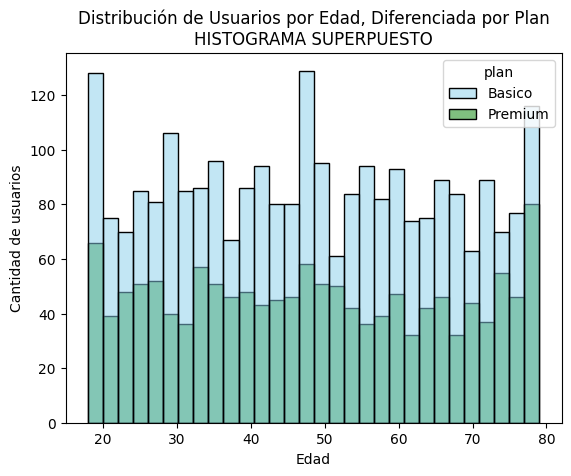

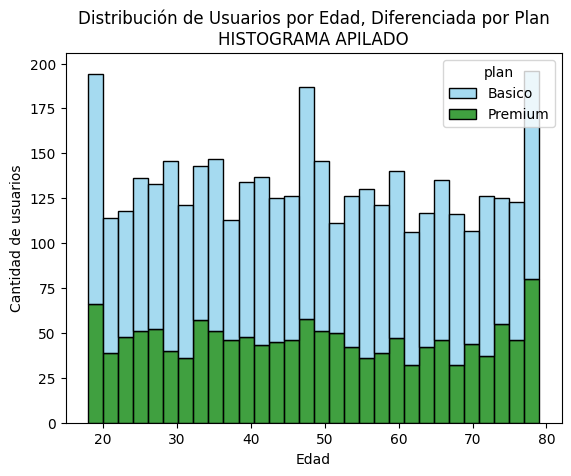

In [30]:

# Histograma para visualizar la edad (age)
varbins = 30
sns.histplot(data=user_profile,x="age" ,hue="plan", bins=varbins,palette=['skyblue','green'])
plt.title("Distribución de Usuarios por Edad, Diferenciada por Plan\nHISTOGRAMA SUPERPUESTO")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

#Adicional: Histograma apilado para observar de mejor manera la cantidad total de usuarios por rango de edades
sns.histplot(data=user_profile,x="age" ,hue="plan", bins=varbins,palette=['skyblue','green'],multiple="stack")
plt.title("Distribución de Usuarios por Edad, Diferenciada por Plan\nHISTOGRAMA APILADO")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

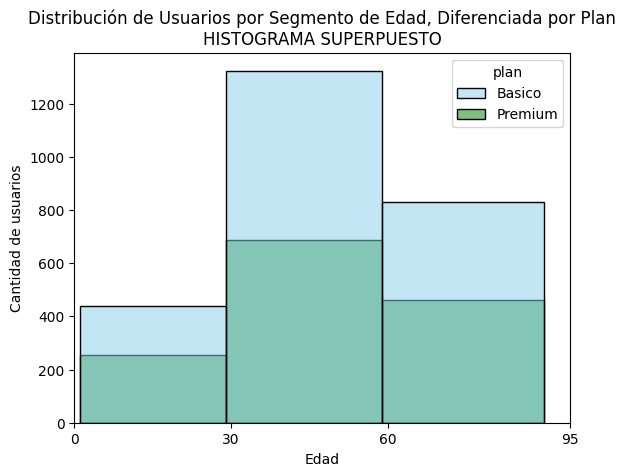

In [31]:
#ADICIONAL: ME PARECIÓ INTERESANTE AGREGAR UN HISTOGRAMA por edades pero definiendo 30, 60 y el resto para que existiera concordancia con el Segmento por Edades (Joven, Adulto y Adulto Mayor) 
# e identificar, dentro de cada Segmento por Edad, la participación de cada plan.
# Histograma para visualizar la edad (age) con bins definidos
sns.histplot(data=user_profile,x="age" ,hue="plan", bins=[1, 29, 59, 90],palette=['skyblue','green'])
plt.title("Distribución de Usuarios por Segmento de Edad, Diferenciada por Plan\nHISTOGRAMA SUPERPUESTO")
plt.xlim(0, 90)
plt.xticks([0, 30, 60, 95])
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights:
- Se observa mayor cantidad de usuarios, independientemente del plan,alrededor los 18, 47 y 77 años
- Los usuarios Básico tienen mayor participación que los Premium en cualquier rango de edades.
- Al colocar "bins=1" se obseva que hay mayor participación del plan Básico sobre el Plan Premium que coincide con la distribución de los planes por usuario del 64.87% y 35.12% respectivamente, tomando en cuenta la información obtenida en puntos anteriores.
- Se evidencia un leve incremento del Plan Premium en personas mayores de 77 años aproximadamente.
- Distribución multimodal, Sin un patrón fuerte y definido visible.

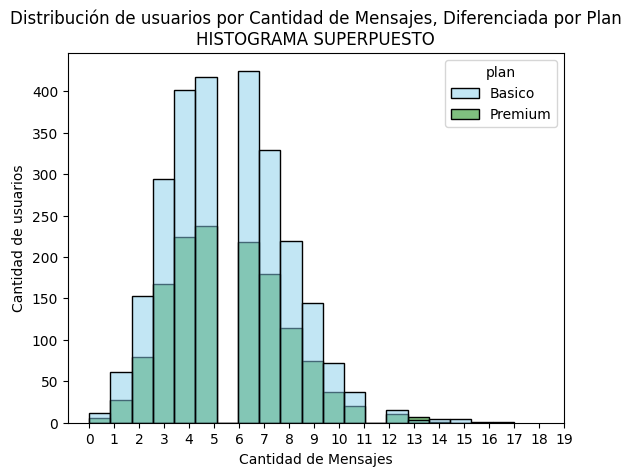

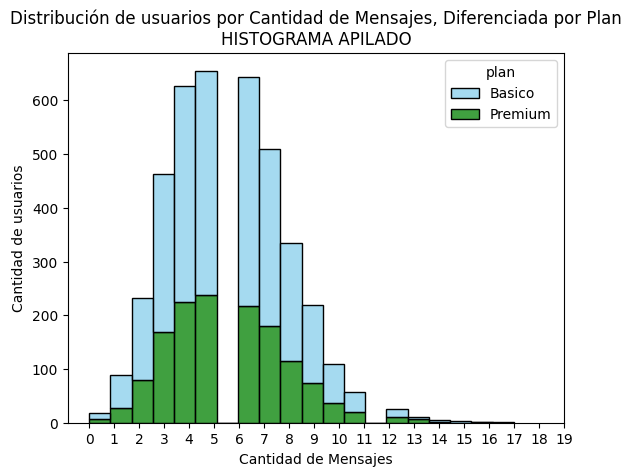

In [32]:
# Histograma para visualizar la cant_mensajes
varbins=20
sns.histplot(data=user_profile,x="cant_mensajes" ,hue="plan", bins=varbins, palette=['skyblue','green'])
plt.title("Distribución de usuarios por Cantidad de Mensajes, Diferenciada por Plan\nHISTOGRAMA SUPERPUESTO")
plt.xticks(range(0, 20, 1))
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()

#Adional: Histograma apilado para observar el total de usuarios por la cantidad de mensajes
sns.histplot(data=user_profile,x="cant_mensajes" ,hue="plan", bins=varbins, palette=['skyblue','green'],multiple="stack")
plt.title("Distribución de usuarios por Cantidad de Mensajes, Diferenciada por Plan\nHISTOGRAMA APILADO")
plt.xticks(range(0, 20, 1))
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- Distribución normal acercándose a la simetría con un poco de sesgo a la derecha.
- Los usuarios tienden a hacer más uso de los mensajes entre 3 y 7 mensajes por año.
- Los usuarios del plan Básico tienen mayor participación que los del plan Premium en cuanto a la cantidad de mensajes enviados en el año 2024.
- Los usuarios de Premium son los que usan más de 13 mensajes en el año 2024.
- Verifiqué la ausencia de datos de la columna "cant_mensajes" entre 5 y 6 aproximadamente. 

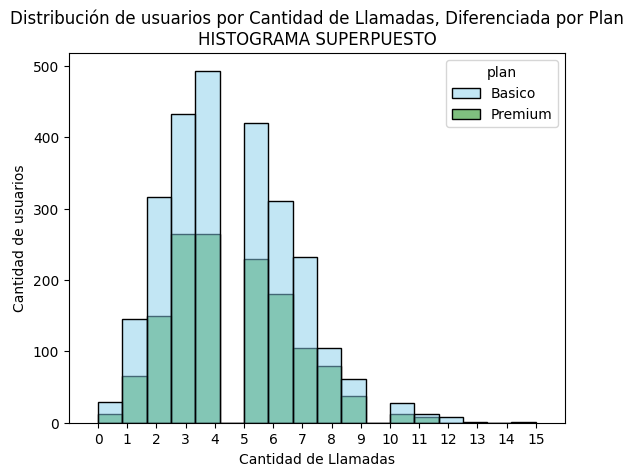

In [33]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile,x="cant_llamadas" ,hue="plan", bins=18,palette=['skyblue','green'])
plt.title("Distribución de usuarios por Cantidad de Llamadas, Diferenciada por Plan\nHISTOGRAMA SUPERPUESTO")
plt.xticks(range(0, 16, 1))
plt.xlim(-1,16)
#plt.ylim(0,9)
plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- Distribución sesgada a la derecha con ausencias en ciertos rangos por Cantidad de Llamadas en el año 2024, lo cual quiere decir que los usuarios hacen pocas llamadas en el año, alrededor de 4 llamadas (mediana) por año en un rango que va hasta 15 llamadas por año.
- Los usuarios en su mayoría tienden a hacer entre 2 y 7 llamadas por el año 2024.
- Los usuarios del plan básico tienen una participación mayor que los del plan Premium en todos los casos en cuanto a la cantidad de llamadas realizadas en el año 2024.
- Si acotamos el eje Y para que muestre un rango de 0 a 9 cantidad de usuarios (plt.ylim(0,9)) nos damos cuenta que quienes hacen más de 12 llamadas en el año son los del Plan Básico.

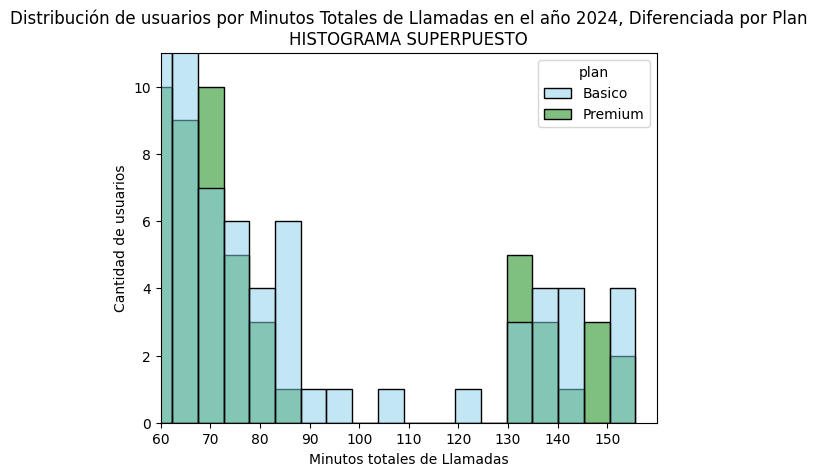

In [34]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,x="cant_minutos_llamada" ,hue="plan", bins=30, palette=['skyblue','green'])
plt.title("Distribución de usuarios por Minutos Totales de Llamadas en el año 2024, Diferenciada por Plan\nHISTOGRAMA SUPERPUESTO")
plt.xticks(range(0, 160, 10))
plt.xlim(60,160)
plt.ylim(0,11)
plt.xlabel("Minutos totales de Llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- Distribución sesgada a la derecha.
- Los usuarios tienden a usar ente 1 y 35 minutos en total de llamadas por el año 2024, concentrándose en los 20 minutos por año 2024.
- Los usuarios de plan básico tienen una mayor participación que los de plan Premium en cuanto a la cantidad de minutos totales en llamadas realizadas en el año 2024.
- Hallazgo extraño: Si hacemos un "zoom" ( plt.xlim(60,160) plt.ylim(0,11) ) dentro del histograma superpuesto, nos damos cuenta que, luego de 130 minutos totales de llamadas en el año 2024, hay una mayor participación del Plan Premium comparado con rangos anteriores a 130 minutos, pero el Plan Básico sigue estando presente de manera importante luego de la ausencia de minutos totales de llamadas por parte del Plan Premium desde 90 hasta 130 minutos totales de llamadas. Estos outlier deben ser materia de investigación o pueden llegar a ser una nueva oportunidad de negocio. Puedes quitar las dos líneas en comentarios para ver esta zona de manera específica.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

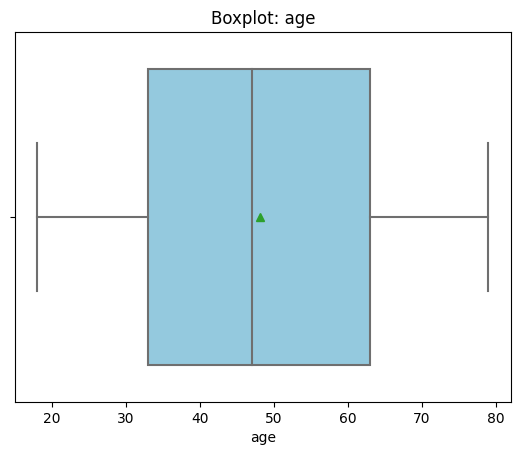

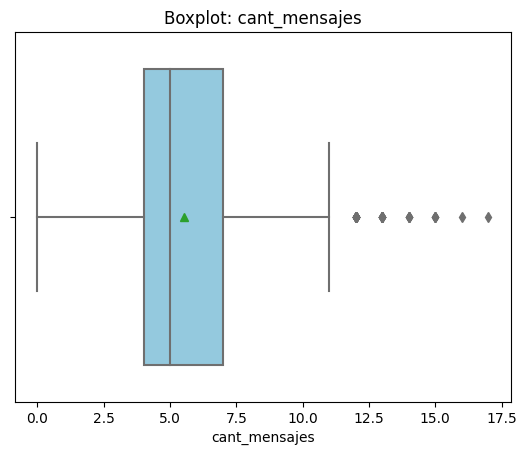

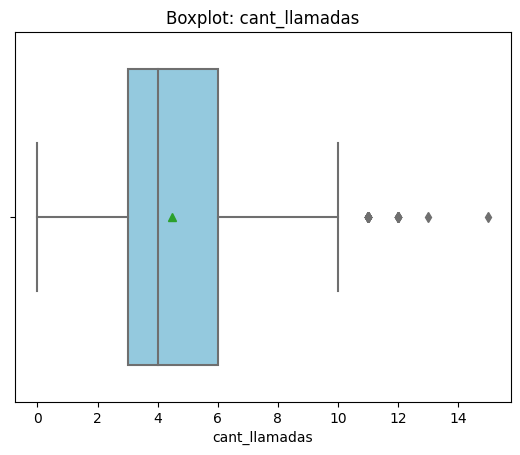

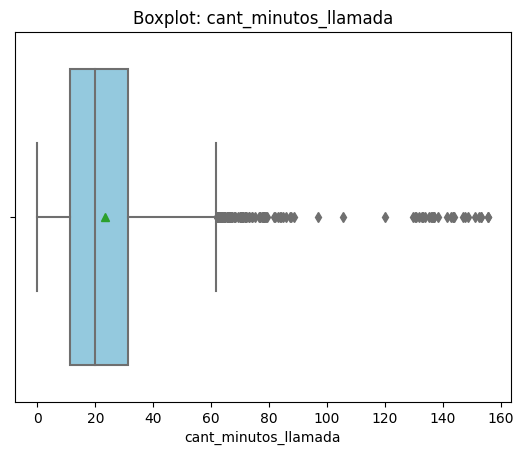

In [35]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col, color='skyblue', showmeans=True )
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 
- Age: no outliers
- cant_mensajes: presenta outliers
- cant_llamadas: presenta outliers
- cant_minutos_llamada: presenta outliers

In [36]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25) #calcular Q1
    Q3 = user_profile[col].quantile(0.75) #calcular Q3
    IQR = Q3 - Q1  #calcular IQR
    limite_superior = Q3 + (1.5*IQR)
    print(f'Límite superior de {col} : {limite_superior}')
    print()

Límite superior de cant_mensajes : 11.5

Límite superior de cant_llamadas : 10.5

Límite superior de cant_minutos_llamada : 61.8575



In [37]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantener. Porque aportan información clave para métricas y segmentación identificando clientes valiosos. No Hay una gran diferencia entre la media y la mediana. No están muy lejos del límite superior y son datos raros pero no imposibles. Pueden tener información para identificar segmentos de clientes potenciales.
- cant_llamadas: Mantener. Porque aportan información clave para métricas y segmentación identificando clientes valiosos. No Hay una gran diferencia entre la media y la mediana. No están muy lejos del límite superior y son datos raros pero no imposibles. Pueden tener información para identificar segmentos de clientes potenciales.
- cant_minutos_llamada: Winsorización.
    - El análisis estadístico requiere moderar su impacto sin eliminarlos.
    - Necesitas estabilizar métricas (mean, std) para modelos o informes.
    - Estabiliza sin perder información.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [38]:
# Crear columna grupo_uso
def clasificacion_uso(row):
    cantidad_llamadas = row["cant_llamadas"]
    cantidad_mensajes = row["cant_mensajes"]

    # 1. Manejo de valores nulos/faltantes
    if pd.isna(cantidad_llamadas) or pd.isna(cantidad_mensajes):
        return "Error en Datos"

    # --- 2. Segmentación de Bajo uso---
    if ((cantidad_llamadas < 5) and (cantidad_mensajes < 5)):
         return "Bajo uso"
            
    # --- 3. Segmentación de Uso medio---
    elif ((cantidad_llamadas < 10) and (cantidad_mensajes < 10)):
         return "Uso medio"
    else: # --- 4. Segmentación de Alto Uso---
         return "Alto uso"

# aplicar función 
user_profile["grupo_uso"] = user_profile.apply(clasificacion_uso,axis=1)


In [39]:
# verificar cambios
print(user_profile[user_profile["cant_llamadas"].isna()])
user_profile.head()

Empty DataFrame
Columns: [user_id, cant_mensajes, cant_llamadas, cant_minutos_llamada, first_name, last_name, age, city, reg_date, plan, churn_date, grupo_uso]
Index: []


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [40]:
# Crear columna grupo_edad
def clasificacion(row):
    age = row["age"]

    # 1. Manejo de valores nulos/faltantes
    if pd.isna(age):
        return "Error en Datos"

    # --- 2. Segmentación de joven---
    if age < 30:
         return "Joven"
            
    # --- 3. Segmentación de Adulto---
    elif age < 60:
         return "Adulto"
        
    # --- 4. Segmentación de Adulto Mayor---
    else: 
         return "Adulto Mayor"

# aplicar función
user_profile["grupo_edad"] = user_profile.apply(clasificacion,axis=1)

In [41]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

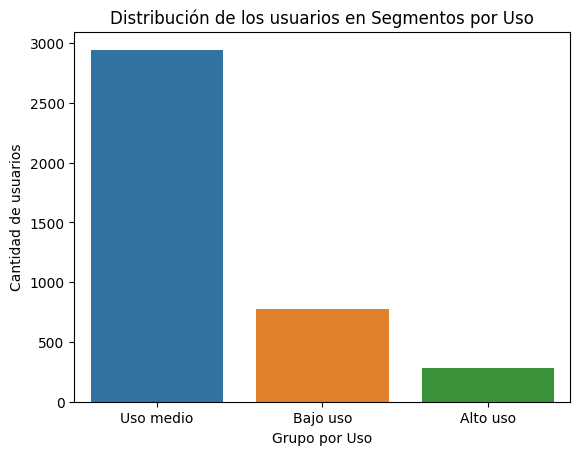

In [42]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso',order=user_profile['grupo_uso'].value_counts().index)
plt.title("Distribución de los usuarios en Segmentos por Uso")
plt.ylabel("Cantidad de usuarios")
plt.xlabel("Grupo por Uso")
plt.show()

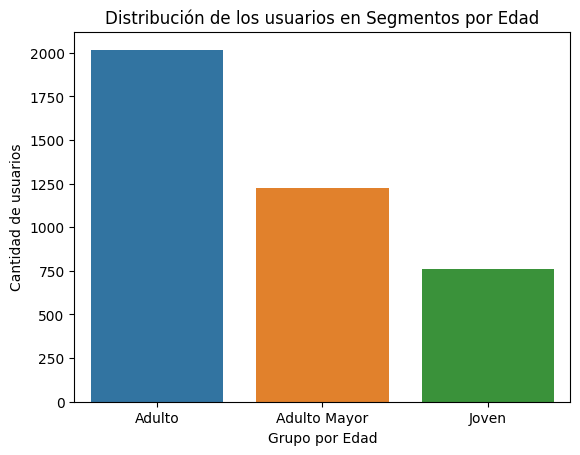

In [43]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', order=user_profile["grupo_edad"].value_counts().index)
plt.title("Distribución de los usuarios en Segmentos por Edad")
plt.ylabel("Cantidad de usuarios")
plt.xlabel("Grupo por Edad")
plt.show()

In [44]:
#ADICIONAL: Tengo un hallazgo que vale la pena analizar teniendo en cuenta la participación de los planes en los "Segmentos por Edad"
print("Distribución porcentual del tipo de plan USADO en todos los usuarios:\n",user_profile["plan"].value_counts(normalize=True)*100,"\n")
print("% para segmento Joven:\n",user_profile[user_profile["grupo_edad"] == "Joven"]["plan"].value_counts(normalize=True)*100,"\n")
print("% para segmento Adulto:\n",user_profile[user_profile["grupo_edad"] == "Adulto"]["plan"].value_counts(normalize=True)*100,"\n")
print("% para segmento Adulto Mayor:\n",user_profile[user_profile["grupo_edad"] == "Adulto Mayor"]["plan"].value_counts(normalize=True)*100, "\n")


Distribución porcentual del tipo de plan USADO en todos los usuarios:
 Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64 

% para segmento Joven:
 Basico     63.947368
Premium    36.052632
Name: plan, dtype: float64 

% para segmento Adulto:
 Basico     65.642043
Premium    34.357957
Name: plan, dtype: float64 

% para segmento Adulto Mayor:
 Basico     64.157119
Premium    35.842881
Name: plan, dtype: float64 




💡Insights ADICIONAL:

- Si nos damos cuenta el porcentaje de participación del plan Básico en cada Segmento por Edad es MUY PARECIDO!!!
    - Joven: 63.947368
    - Adulto : 65.642043
    - Adulto Mayor: 64.157119
- De igual manera el porcentaje de participación del plan Premium en cada Segmento por Edad es MUY PARECIDO!!!
    - Joven : 36.052632
    - Adulto : 34.357957
    - Adulto Mayor : 35.842881


In [45]:
#ADICIONAL: Tengo un hallazgo que vale la pena analizar teniendo en cuenta la participación de los planes en los "Segmentos por Uso"
print("Distribución porcentual del tipo de plan USADO en TODOS los usuarios:\n",user_profile["plan"].value_counts(normalize=True)*100,"\n")
print("% para segmento Bajo Uso:\n",user_profile[user_profile["grupo_uso"] == "Bajo uso"]["plan"].value_counts(normalize=True)*100,"\n")
print("% para segmento Uso Medio:\n",user_profile[user_profile["grupo_uso"] == "Uso medio"]["plan"].value_counts(normalize=True)*100,"\n")
print("% para segmento Alto Uso:\n",user_profile[user_profile["grupo_uso"] == "Alto uso"]["plan"].value_counts(normalize=True)*100, "\n")

Distribución porcentual del tipo de plan USADO en TODOS los usuarios:
 Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64 

% para segmento Bajo Uso:
 Basico     65.809769
Premium    34.190231
Name: plan, dtype: float64 

% para segmento Uso Medio:
 Basico     64.458036
Premium    35.541964
Name: plan, dtype: float64 

% para segmento Alto Uso:
 Basico     66.546763
Premium    33.453237
Name: plan, dtype: float64 



💡Insights ADICIONAL:

- Si nos damos cuenta el porcentaje de participación del plan Básico en cada Segmento por Uso es MUY PARECIDO!!!
    - Bajo uso: 65.809769
    - Uso medio: 64.458036
    - Alto uso: 66.546763
- De igual manera el porcentaje de participación del plan Premium en cada Segmento por Uso es MUY PARECIDO!!!
    - Bajo uso: 34.190231
    - Uso medio: 35.541964
    - Alto uso: 33.453237



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En el DataSet "usage":
    - "date": 50 registros con NaN, el 0.125% de 40000 registros en total. Por su porcentaje tan bajo, eliminar esas filas no introduce un sesgo importante. Tipo de valor ausente MCAR. Deben dejarse NaN.
- En el DataSet "users":
    - "age": con sentinela -999 en 55 filas que es el 1.37% de 4000 reg total. Se debe reemplazar por la mediana.
    - "city":
        - hay con NaN 469 reg que es el 11.72%--- MCAR deben dejarse NaN
        - con sentinela "?" en 96 filas que es el 2.4% de 4000 reg total. La solución es reemplazarlas por NaN.
    - "reg_date": Se encontró  año en 2026(fuera de rango) en 40 filas que es el 1% de 4000 reg total. La solución es reemplazarlas por NaN.

---
Se identificaron dos segmentos sobre los clientes, a saber:

🔍 **Segmentos por Edad**
- Hay mayor cantidad de usuarios en el segmento de "Adultos" ( de 30 a 59 años ), seguido por "Adulto Mayor" ( de 60 años en adelante ) y con la menor cantidad de usuarios el segmento de "Joven".
- **Segmento por Edad Vs. Histograma ADICIONAL** = Distribución de Usuarios en Segmento por Edad, **Diferenciada por Plan**
- En cada uno de los segmentos, los usuarios Básicos tienen mayor participación que los usuarios Premium, de acuerdo a Histograma adicional visualizado en la sección de Histogramas, hasta el punto que en todos los segmentos casi que lo duplican.
- Si nos damos cuenta el porcentaje de participación del plan Básico en cada Segmento por Edad es MUY PARECIDO!!!
    - Joven: 63.947368
    - Adulto : 65.642043
    - Adulto Mayor: 64.157119
- De igual manera el porcentaje de participación del plan Premium en cada Segmento por Edad es MUY PARECIDO!!!
    - Joven : 36.052632
    - Adulto : 34.357957
    - Adulto Mayor : 35.842881
- Esto define un patrón muy fuerte entre el porcentaje de la participación de los dos planes en todos los Segmentos por Edad.
      
📊 **Segmentos por Nivel de Uso**
- El uso Medio es el que más cantidad de usuarios presenta; lo sigue el Bajo Uso y con la menor cantidad de usuario el Alto Uso.
- El segmento más importante para ConnectaTel es el medio porque tiene mayor cantidad de usuarios activos que usan los servicios.
- Si nos damos cuenta el porcentaje de participación del plan Básico en cada Segmento por Uso es MUY PARECIDO!!!
    - Bajo uso: 65.809769
    - Uso medio: 64.458036
    - Alto uso: 66.546763
- De igual manera el porcentaje de participación del plan Premium en cada Segmento por Uso es MUY PARECIDO!!!
    - Bajo uso: 34.190231
    - Uso medio: 35.541964
    - Alto uso: 33.453237
- Esto define un patrón muy fuerte entre el porcentaje de la participación de los dos planes en todos los Segmentos por Uso.


➡️**Esto sugiere que :** 
- ConnectaTel podría revisar sus planes para mejorar la experiencia de los usuarios.
- Sería bueno analizar a los usuarios con alto consumo.
- Investigar las llamadas que generan outliers en la métrica "Cantidad de minutos en llamdas" para detectar irregularidades o errores.
- Considerar los segmentos de uso MEDIO y ADULTO como los segmentos más importantes para la Compañía.
- Segmentar por Ciudad  y luego por Ciudad-Edad
- Comparar con otros años para establecer la diferencias de crecimiento.
- Establecer una relación más clara entre edad y qué tipo de servicio usa.

💡 **Recomendaciones**
- En los outliers identificados en la "Cantidad de minutos usados en llamadas" sería interesante identificar e investigar las llamadas que se presentaron luego de los 130 minutos totales en el año 2024, ya que podría corresponder a un error de ingreso de datos y se debería corregir ese error, podría ser un fraude o en el mejor de los casos se podría presentar como una nueva oportunidad de negocio con clientes potenciales por la notable presencia de clientes con planes Premium.
- Se recomienda modificar los planes para Adulto Mayor teniendo en cuenta su moderada participación en el segmento por edad con el fin de incentivar el consumo de los dos servicios y prepararlos a que en un futuro migren a Premium.
- Estudiar a profundidad las campañas de mercadeo y planes ofrecidos a Adultos con el fin de identificar qué elementos hacen que este segmento tenga la mayor participación por edades y replicarlos en los otros grupos AJUSTÁNDOLOS a la condición de cada segmento en particular. De igual manera ofrecerles una migración al plan Premium.
- Se recomienda crear una oferta intermedia para usuarios de uso medio, ya que este grupo concentra una parte importante de los clientes y podría beneficiarse de un plan con más minutos o mensajes antes de migrar a Premium.
- Se recomienda revisar a los usuarios de alto consumo para identificar si el plan actual cubre sus necesidades o si conviene ofrecerles una migración al plan Premium, especialmente si presentan muchos minutos o mensajes por encima del promedio.
- Hacer una campaña de mercadeo intensiva sobre el grupo de los Jóvenes con un NUEVO PLAN destinado a satisfacer las necesidades específicas de este grupo teniendo en cuenta que es la de menor participación en el Segmento por Edades y a sabiendas del gran mercado cautivo existente en el mercado.
- Modificar el algoritmo de clasificación en la segmentación por uso, de tal manera que no solo tome la cantidad de uso del servicio, sino que incluya la frecuencia en que se usa cada servicio aprovechando que se tiene ese dato en el DataSet. De esta manera se le puede asignar a cada atributo de cada servicio un peso dependiendo de su importancia que nos dé como resultado una magnitud medible más precisa y que involucre toda la inteligencia del negocio.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`